In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
from google.colab import files
uploaded = files.upload()

Saving desafio_nps_fase_1.csv to desafio_nps_fase_1 (1).csv


In [14]:
df = pd.read_csv("desafio_nps_fase_1.csv")
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [15]:
def categorizar_nps(score):
    if score <= 6:
        return "Detrator"
    elif score <= 8:
        return "Neutro"
    else:
        return "Promotor"

df["nps_categoria"] = df["nps_score"].apply(categorizar_nps)

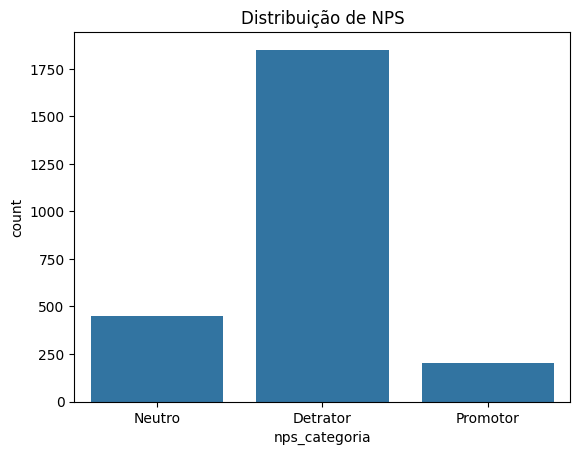

In [16]:
sns.countplot(data=df, x="nps_categoria")
plt.title("Distribuição de NPS")
plt.show()

In [17]:
df["atraso_grupo"] = df["delivery_delay_days"].apply(
    lambda x: "Maior que 2 dias" if x > 2 else "Até 2 dias"
)

pd.crosstab(
    df["atraso_grupo"],
    df["nps_categoria"],
    normalize="index"
)

nps_categoria,Detrator,Neutro,Promotor
atraso_grupo,,,
Até 2 dias,0.620936,0.252926,0.126138
Maior que 2 dias,0.931393,0.061331,0.007277


In [19]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

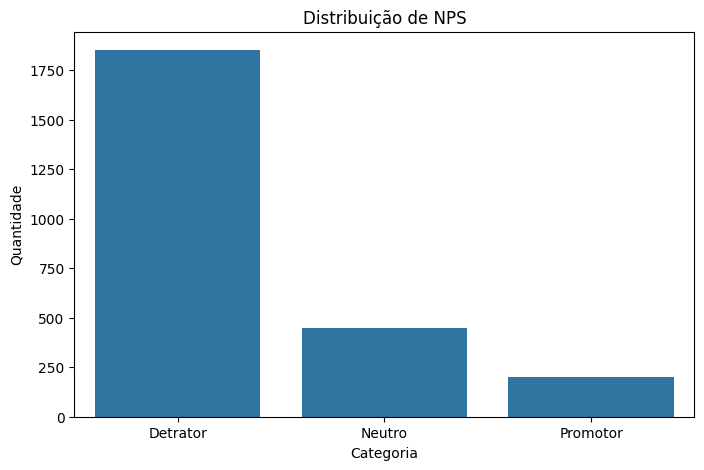

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="nps_categoria",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Distribuição de NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")

plt.show()

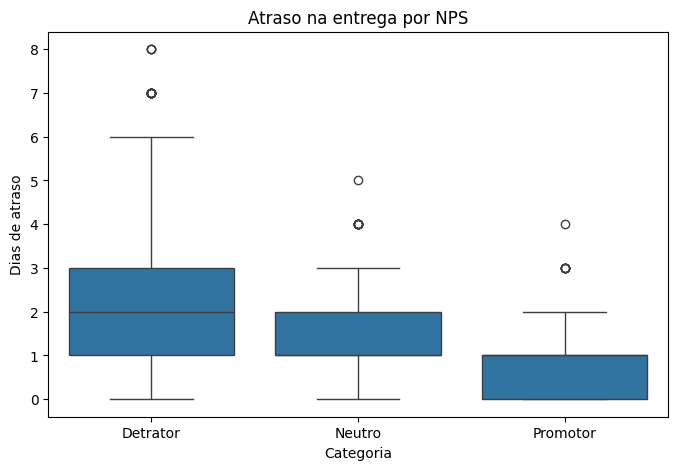

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="nps_categoria",
    y="delivery_delay_days",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Atraso na entrega por NPS")
plt.xlabel("Categoria")
plt.ylabel("Dias de atraso")

plt.show()

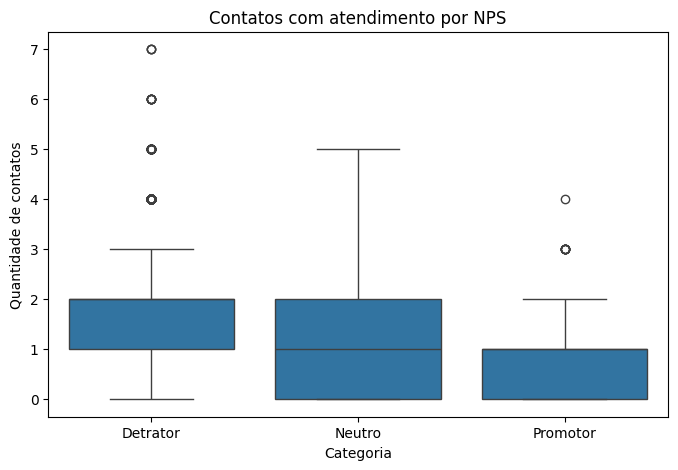

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="nps_categoria",
    y="customer_service_contacts",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Contatos com atendimento por NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de contatos")

plt.show()

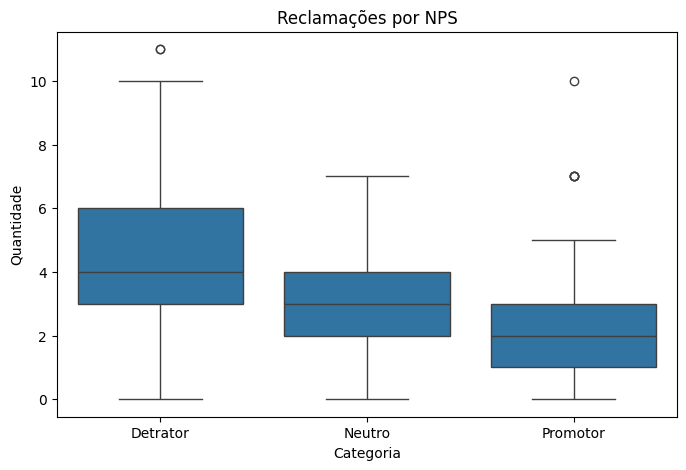

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="nps_categoria",
    y="complaints_count",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Reclamações por NPS")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")

plt.show()

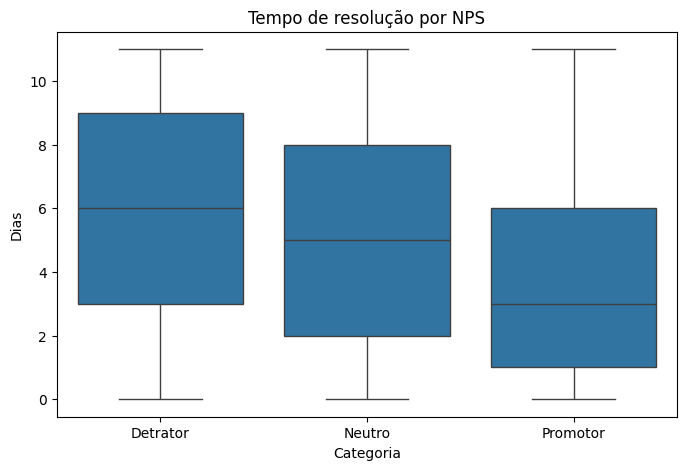

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="nps_categoria",
    y="resolution_time_days",
    order=["Detrator", "Neutro", "Promotor"]
)

plt.title("Tempo de resolução por NPS")
plt.xlabel("Categoria")
plt.ylabel("Dias")

plt.show()

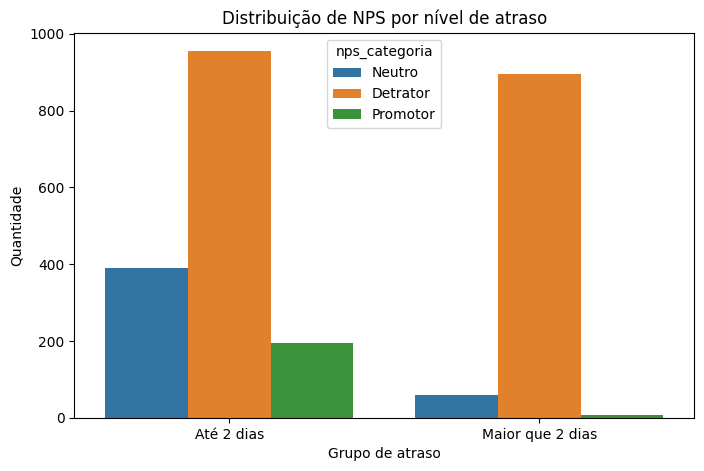

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="atraso_grupo",
    hue="nps_categoria"
)

plt.title("Distribuição de NPS por nível de atraso")
plt.xlabel("Grupo de atraso")
plt.ylabel("Quantidade")

plt.show()